# Customer Churn Prediction

## Business Problem
A telecom company wants to identify customers likely to churn so that retention teams can proactively engage them.

## Objective
Build an end-to-end machine learning model to predict customer churn.

In [11]:
# Importing the required libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import sklearn
%matplotlib inline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [12]:
import sys
print(sys.executable)

c:\Users\jasmeetkaur02\Documents\NAGP\data-science\.venv\Scripts\python.exe


In [13]:
# Importing required packages for visualization
from IPython.display import Image  
# from sklearn.externals.six import StringIO  
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus, graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

## Data Understanding & Preparation

### Data Loading

In [14]:
import pandas as pd

# Reading the csv file and putting it into 'df' object.
df = pd.read_csv("data/TelcoCustomerChurn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [16]:
df.shape


(7043, 21)

### Data Types

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Summary Statistics

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Numerical and categorical feature identification

In [19]:
#Check numeric columns
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [21]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [20]:
# Check categorical columns
df.select_dtypes(exclude=np.number).columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

### Important Observations

- Dataset contains 7,043 records and 21 columns.
- Three numerical features were identified before data cleaning.
- Most variables are categorical/non-numerical.
- customerID acts as an identifier.

### Missing Value Analysis

#### Check missing values

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Check blanks

In [23]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [27]:
# Check numeric columns again after filling NaN values
df.select_dtypes(include=np.number).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

#### Observation

- Missing values were found in the **`TotalCharges`** column.  
- These occur because some customers have a **tenure of 0 months** — they are new customers who have not yet been billed. As a result, their total charges are unavailable and appear as blank values in the dataset.  
- Before imputation, the dataset contained **11 missing values** in `TotalCharges`.  
- These corresponded exclusively to customers with **tenure = 0**.  


### Duplicate Analysis

In [44]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

#### Observation

No duplicate records were found in the dataset.

### Target variable analysis

In [46]:
# Check the target variable distribution
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [47]:
# Check the target variable distribution in percentage
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

#### Observation

Approximately 26.5% of customers churned,
while 73.5% remained with the company.

### Train Test Split
70:30 split as required
random_state=42 for reproducibility


#### Prepare X and Y

In [ ]:
# Prepare the features and target variable for modeling
X = df.drop("Churn", axis=1)

y = df["Churn"]
X
y

#### Split

In [ ]:
# Split the dataset into training and testing sets
# 70:30 split with random_state=42 used for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
print("TRAIN X SHAPE:",X_train.shape)
print("TRAIN Y SHAPE:",y_train.shape)
print("VALUE COUNTS:\n",y_train.value_counts())
print("TEST X SHAPE :",X_test.shape)
print("TEST Y SHAPE :",y_test.shape)

### Data cleaning and Preprocessing

#### Fix TotalCharges data type

     The TotalCharges column was initially read as an object due to blank values.Converted to numeric.

In [ ]:
# Convert TotalCharges to numeric, coercing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

#### Handle Missing Values

Median imputation ensured all 7,043 records were retained.
Dataset now contains four numerical features (tenure, MonthlyCharges, TotalCharges, SeniorCitizen).

In [ ]:
# Fill NaN values with median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

#### Drop unnecessary columns

In [ ]:
# Data Preprocessing - Drop customerID column
df.drop("customerID", axis=1, inplace=True)

#### Observation
- Before imputation, the dataset contained **11 missing values** in `TotalCharges`.  
- Median imputation was chosen because:  
  - `TotalCharges` is a numerical feature.  
  - Its distribution is **right‑skewed**, with some customers having very high charges.  
  - The **median** is less affected by outliers than the mean, making it a more robust measure of central tendency.  
  - This approach preserves the overall distribution while retaining all records for analysis and model training.  
- After applying median imputation, **all missing values were replaced**, resulting in a dataset with **7,043 complete records** and no nulls.  
- The dataset now contains **four numerical features** (`tenure`, `MonthlyCharges`, `TotalCharges`, and `SeniorCitizen`), with the remaining variables categorical.  



In [ ]:
# Check NaNs after conversion
print(df["TotalCharges"].isna().sum())

11


In [30]:
# Check the target variable distribution in percentage
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Encoding of Categorical Data
Machine learning models such as Decision Trees require numerical input. Therefore, categorical variables were converted into numerical representations using one-hot encoding. The parameter drop_first=True was used to avoid redundant dummy variables and reduce multicollinearity.


In [48]:
# Convert the target variable to numeric so that the target value is not renamed 
# during one-hot encoding
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})


In [49]:
# Convert categorical variables to dummy variables using one-hot encoding
df = pd.get_dummies(
    df,
    drop_first=True
)

## Exploratory Data Analysis

### Chart 1: Churn Distribution

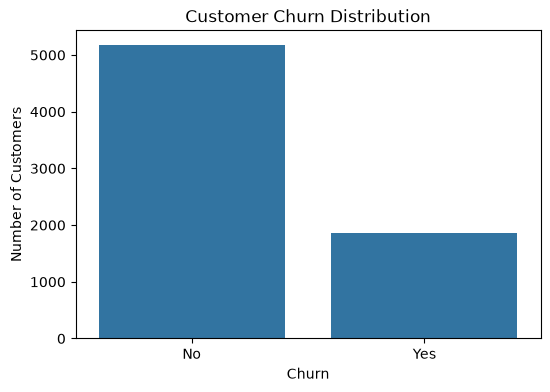

In [33]:
# Visualize the target variable distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


#### Business Insight:

The majority of customers have been retained, while a significant proportion have churned.
Customer attrition remains a key business concern as it directly impacts recurring revenue and customer lifetime value.
Retention strategies should focus on identifying and engaging customers at risk of leaving.

### Chart 2: Contract vs Churn

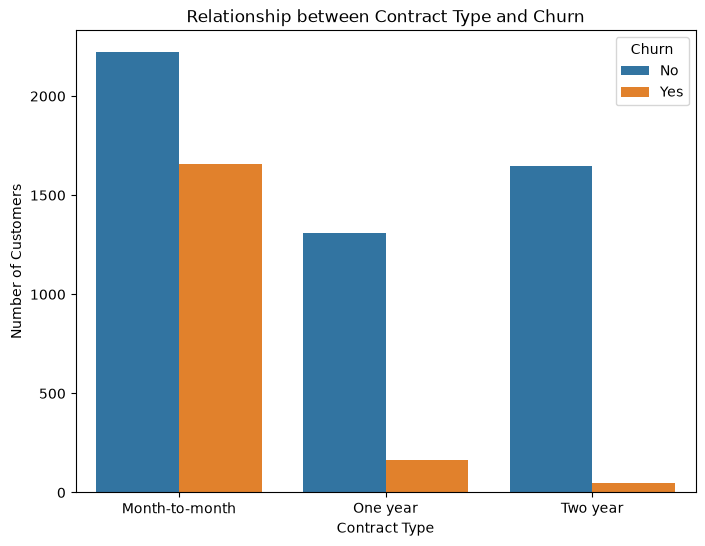

In [34]:
# Visualize the relationship between Contract type and Churn
plt.figure(figsize=(8,6))
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)
plt.title("Relationship between Contract Type and Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

#### Business Insight:

Customers with month-to-month contracts show the highest churn rates.
Customers on one-year and two-year contracts are more likely to stay with the company.
Promoting long-term contracts through discounts and loyalty benefits could help reduce churn.

### Chart 3: Tenure vs Churn

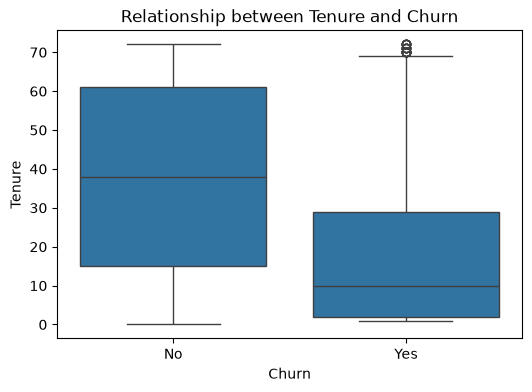

In [35]:
# Visualize the relationship between tenure and Churn
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)
plt.title("Relationship between Tenure and Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

#### Business Insight:

Churned customers generally have lower tenure than retained customers.
New customers are more likely to leave, while long-term customers tend to be more loyal.
Improving onboarding and early customer engagement may help reduce churn among newer customers.

### Chart 4: MonthlyCharges vs Churn

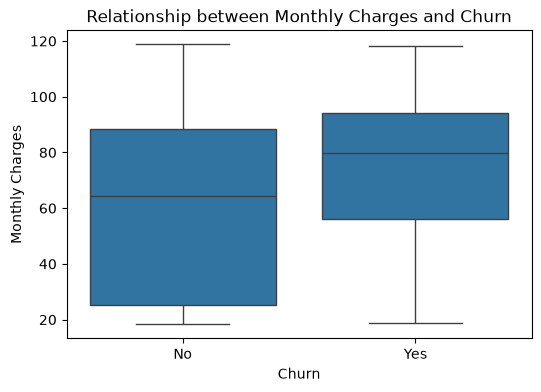

In [36]:
# Visualize the relationship between Monthly Charges and Churn
plt.figure(figsize=(6,4))
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)
plt.title("Relationship between Monthly Charges and Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### Business Insight:

Customers who churn tend to have higher monthly charges on average.
Higher service costs may increase customer dissatisfaction or encourage customers to switch to competitors.
The company should evaluate pricing strategies and ensure high-value plans deliver sufficient benefits.

### Chart 5: InternetService vs Churn

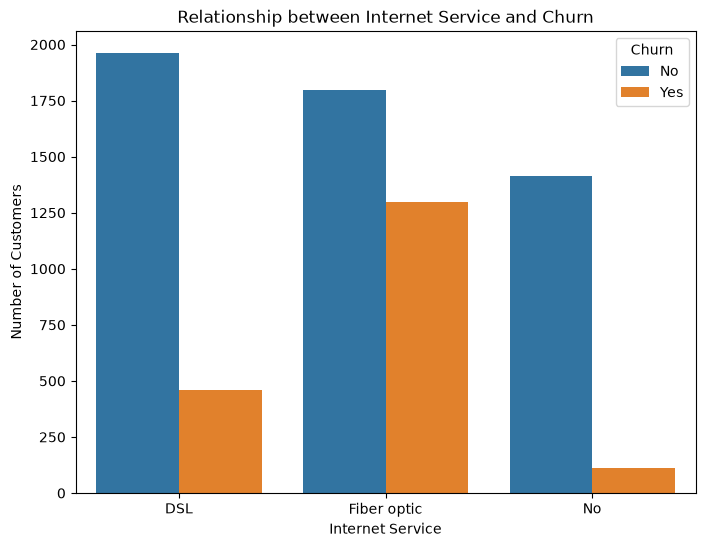

In [38]:
# Visualize the relationship between Internet Service and Churn
plt.figure(figsize=(8,6))
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)
plt.title("Relationship between Internet Service and Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

#### Business Insight:

Customers using Fiber Optic internet services exhibit higher churn rates compared to DSL customers.
This may indicate concerns related to pricing, service quality, or customer expectations within the Fiber Optic segment.
Further investigation into Fiber Optic customer satisfaction could help identify opportunities to improve retention.

### Overall Conclusion

The analysis indicates that churn is strongly associated with short customer tenure, month-to-month contracts, higher monthly charges, and Fiber Optic internet service. Customers on long-term contracts and those with longer tenure demonstrate greater loyalty. Therefore, customer retention efforts should focus on new customers, high-billing customers, and month-to-month contract subscribers.

## Feature Engineering

### Feature Name: AvgMonthlySpend

Creation Method: Calculated as TotalCharges divided by tenure.

Business Rationale: Represents customer spending behavior.

In [ ]:
df["AvgMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

### Feature Name: ServiceCount

Creation Method: Counted the number of value-added services (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) subscribed to by each customer.

Business Rationale: Customers using more services are generally more integrated into the company's ecosystem and may have a lower likelihood of churning. This feature captures customer engagement in a single variable and can improve churn prediction.

In [ ]:
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = (
    df[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

### Model Development

#### Model 1: Baseline Decision Tree

**Description:**  
A baseline Decision Tree Classifier with a maximum depth of 3.  
This shallow tree is chosen to keep the model simple, interpretable, and less prone to overfitting.

**Key Hyperparameter:**  
- **max_depth = 3**

**Reproducibility Setting:**  
- **random_state = 42**  
  (used to ensure consistent results across runs, but does not affect the model’s learning capacity)


In [ ]:
# Model 1

dt1 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt1.fit(X_train, y_train)

#### Model 2: Tuned Decision Tree

**Description:**  
A more complex Decision Tree Classifier with a maximum depth of 6 and a minimum sample split requirement of 10.  
This configuration is designed to capture more complex customer churn patterns while reducing the risk of overfitting by preventing splits on very small groups of observations.

**Key Hyperparameters:**  
- **max_depth = 6**
  - Allows the tree to grow deeper and learn more detailed decision rules.
- **min_samples_split = 10**
  - Requires at least 10 samples in a node before it can be split, helping to avoid creating overly specific branches.

**Reproducibility Setting:**  
- **random_state = 42**
  - Ensures consistent and reproducible results across runs.

**Purpose of Comparison:**  
This model is compared against the baseline model to determine whether increased tree complexity improves churn prediction performance. Evaluation metrics such as Accuracy, Precision, Recall, and F1 Score will be used to select the final model.

In [ ]:
# Model 2

dt2 = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

dt2.fit(X_train, y_train)

#### Evaluating model performance

Creating helper functions to evaluate model performance and help plot the decision tree

In [ ]:
def get_dt_graph(dt_classifier):
    dot_data = StringIO()
    export_graphviz(dt_classifier, out_file=dot_data, filled=True,rounded=True,
                    feature_names=X.columns, 
                    class_names=['No', 'Yes'])
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph

In [ ]:
def evaluate_model(model):
    pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test,pred), flush=True)
    print("Precision:",
          precision_score(y_test,pred))
    print("Recall:",
          recall_score(y_test,pred))
    print("F1:",
          f1_score(y_test,pred))
    print(confusion_matrix(
          y_test,pred))

In [ ]:
evaluate_model(dt1)

In [ ]:
evaluate_model(dt2)

In [ ]:
gph = get_dt_graph(dt1)


In [ ]:
Image(gph.create_png())

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(dt1, filled=True)
plt.show()


### Specifying minimum samples before split

In [ ]:
dt_min_split = DecisionTreeClassifier(min_samples_split=20)
dt_min_split.fit(X_train, y_train)

In [ ]:
gph = get_dt_graph(dt_min_split) 
Image(gph.create_png())

In [ ]:
evaluate_model(dt_min_split)

### Specifying minimum samples in leaf node

In [ ]:
dt_min_leaf = DecisionTreeClassifier(min_samples_leaf=20, random_state=42)
dt_min_leaf.fit(X_train, y_train)

In [ ]:
gph = get_dt_graph(dt_min_leaf)
Image(gph.create_png())

In [ ]:
evaluate_model(dt_min_leaf)

### Using Entropy instead of Gini

In [ ]:
dt_min_leaf_entropy = DecisionTreeClassifier(min_samples_leaf=20, random_state=42, criterion="entropy")
dt_min_leaf_entropy.fit(X_train, y_train)

In [ ]:
gph = get_dt_graph(dt_min_leaf_entropy)
Image(gph.create_png())

In [ ]:
evaluate_model(dt_min_leaf_entropy)

### Hyper-parameter tuning

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Create the parameter grid based on the results of random search 
params = {
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}


In [ ]:
# grid_search = GridSearchCV(estimator=dt, 
#                            param_grid=params, 
#                            cv=4, n_jobs=-1, verbose=1, scoring = "f1")

In [ ]:
# Instantiate the grid search model
grid_search = GridSearchCV(estimator=dt, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")

In [ ]:
%%time
grid_search.fit(X_train, y_train)

In [ ]:
score_df = pd.DataFrame(grid_search.cv_results_)
score_df.head()

In [ ]:
score_df.nlargest(5,"mean_test_score")

In [ ]:
grid_search.best_estimator_

In [ ]:
dt_best = grid_search.best_estimator_

In [ ]:
evaluate_model(dt_best)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, dt_best.predict(X_test)))

In [ ]:
gph = get_dt_graph(dt_best)
Image(gph.create_png())